In [1]:
from instruments.pypcocam import PcoCamera
from instruments.monochromator.mono import MonochromatorControl
from instruments.filterwheel import FilterWheelControl

import matplotlib.pyplot as plt
import numpy as np

FILTER_ADDRESS = 'USB0::0x104D::0x1011::7A01020F12162064::RAW'
CAMERA_SERIAL = "22500190"
MONO_PORT = "COM3"

In [2]:
# Init instruments
filterwheel = FilterWheelControl(FILTER_ADDRESS)
mono = MonochromatorControl(MONO_PORT)
camera = PcoCamera(serial=CAMERA_SERIAL)

# Go to default
filterwheel.set_position(1)

mono.initialize_arduino()
mono.home_motor()
mono.select_grating_mode(mode="VIS Grating")
mono.set_wavelength(550.0)

camera.set_roi(camera._sensor_width - 1000, camera._sensor_height)
camera.set_exposure_ms(200.0)

Connected to COM3; you can now initialize the Monochromator.
Camera 22500190 is connected
INFO: monochromator initialized; send `home` to start
INFO: homing
ADC: 303
OK: homed
OK: mode VIS
INFO: moving 550.00
OK: wavelength 550.00


In [3]:
wavelengths = np.linspace(400, 1000, 121)
images = np.zeros((len(wavelengths), camera.image_height,camera.image_width))

filterwheel.set_position(1)
camera.arm()
for idx, wavelength in enumerate(wavelengths):
    if wavelength >= 600:
        filterwheel.set_position(3)
    mono.set_wavelength(wavelength)
    images[idx] = camera.get_image()[..., 0]

camera.disarm()
mono.set_wavelength(550.0)
filterwheel.set_position(1)

INFO: moving 400.00
OK: wavelength 400.00
INFO: moving 405.00
OK: wavelength 405.00
INFO: moving 410.00
OK: wavelength 410.00
INFO: moving 415.00
OK: wavelength 415.00
INFO: moving 420.00
OK: wavelength 420.00
INFO: moving 425.00
OK: wavelength 425.00
INFO: moving 430.00
OK: wavelength 430.00
INFO: moving 435.00
OK: wavelength 435.00
INFO: moving 440.00
OK: wavelength 440.00
INFO: moving 445.00
OK: wavelength 445.00
INFO: moving 450.00
OK: wavelength 450.00
INFO: moving 455.00
OK: wavelength 455.00
INFO: moving 460.00
OK: wavelength 460.00
INFO: moving 465.00
OK: wavelength 465.00
INFO: moving 470.00
OK: wavelength 470.00
INFO: moving 475.00
OK: wavelength 475.00
INFO: moving 480.00
OK: wavelength 480.00
INFO: moving 485.00
OK: wavelength 485.00
INFO: moving 490.00
OK: wavelength 490.00
INFO: moving 495.00
OK: wavelength 495.00
INFO: moving 500.00
OK: wavelength 500.00
INFO: moving 505.00
OK: wavelength 505.00
INFO: moving 510.00
OK: wavelength 510.00
INFO: moving 515.00
OK: wavelength

(1500.0, 2000.0)

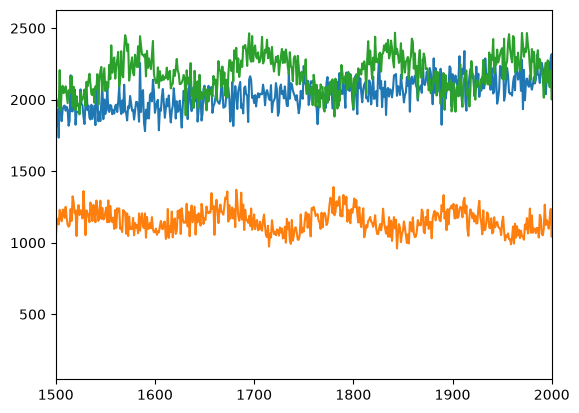

In [4]:
plt.plot(images[0, 1000])
plt.plot(images[113, 1000])
plt.plot(images[120, 1000])
plt.xlim([1500, 2000])

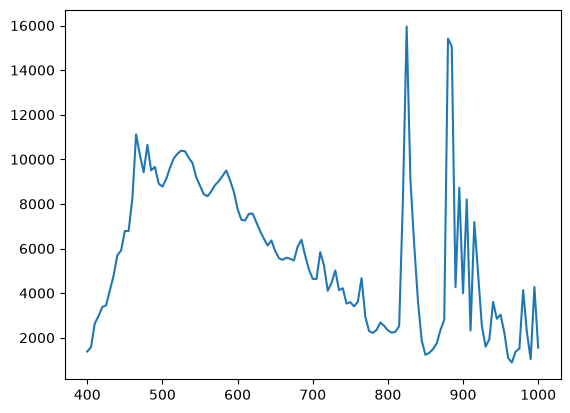

In [5]:
plt.plot(wavelengths, images.mean(axis=(1, 2)))